# TP5 — Machine Learning : Régression sur le Béton

**Dataset :** mergedDatasets — Prédire la **Résistance du béton**

**Variables d'entrée (X) :** Ciment, Laitier, Cendres volantes, Eau,
Superplastifiant, Gros granulat, Granulat fin, Age

**Variable cible (y) :** Résistance

---

# I. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, median_absolute_error)

# II. Load Data

### 1. Importer le fichier de données

In [4]:
df = pd.read_excel('mergedDatasets.xlsx')

In [5]:
df.head()

,Ciment,Laitier,Cendres volantes,Eau,Superplastifiant,Gros granulat,Granulat fin,Age,Résistance
0,298.20,0.0,107.00,209.70,11.10,879.6,744.20,28,31.875165
1,397.00,0.0,0.00,186.00,0.00,1040.0,734.00,28,36.935229
2,251.37,0.0,118.27,188.45,6.35,1028.4,757.73,56,36.638755
3,304.00,140.0,0.00,214.00,6.00,895.0,722.00,28,33.418902
4,297.00,0.0,0.00,186.00,0.00,1040.0,734.00,7,30.957472


### 2. Vérifier les doublons

In [6]:
duplicated=df[df.duplicated()]
len(duplicated)

38

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

0

In [13]:
df.shape

(1764, 9)

Index(['Ciment', 'Laitier', 'Cendres volantes', 'Eau', 'Superplastifiant',
       'Gros granulat', 'Granulat fin', 'Age', 'Résistance'],
      dtype='str')

### 3. Afficher les colonnes et leurs types

In [16]:
df.columns

Index(['Ciment', 'Laitier', 'Cendres volantes', 'Eau', 'Superplastifiant',
       'Gros granulat', 'Granulat fin', 'Age', 'Résistance'],
      dtype='str')

In [18]:
df.dtypes

Ciment              float64
Laitier             float64
Cendres volantes    float64
Eau                 float64
Superplastifiant    float64
Gros granulat       float64
Granulat fin        float64
Age                   int64
Résistance          float64
dtype: object

# III. Data Description

### 1. Dimension du dataset

In [19]:
print('Lignes :', df.shape[0])
print('Colonnes :', df.shape[1])


Lignes : 1764
Colonnes : 9


### 2. Description statistique

In [20]:
df.describe()


,Ciment,Laitier,Cendres volantes,Eau,Superplastifiant,Gros granulat,Granulat fin,Age,Résistance
count,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000
mean,278.750862,73.364637,54.704898,182.359495,5.964147,973.624705,771.972319,45.509637,35.242929
std,104.425008,86.698967,64.005061,21.140041,5.868398,77.344730,80.132732,62.486939,16.340216
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.340000,0.000000,0.000000,167.000000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,266.000000,21.000000,0.000000,185.700000,6.000000,968.000000,778.900000,28.000000,33.745000
75%,342.000000,142.500000,118.300000,192.955000,10.000000,1029.400000,822.000000,56.000000,45.080000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### 3. Vérification des valeurs manquantes

In [21]:
print(df.isnull().sum())
print()
print('Total valeurs manquantes :', df.isnull().sum().sum())


Ciment              0
Laitier             0
Cendres volantes    0
Eau                 0
Superplastifiant    0
Gros granulat       0
Granulat fin        0
Age                 0
Résistance          0
dtype: int64

Total valeurs manquantes : 0


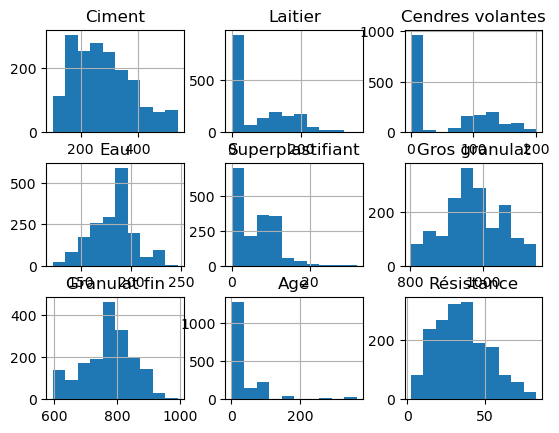

In [23]:
df.hist()
plt.show()

# IV. Visualisation et Nettoyage des Données

### 1. Boxplots — Détecter les Outliers

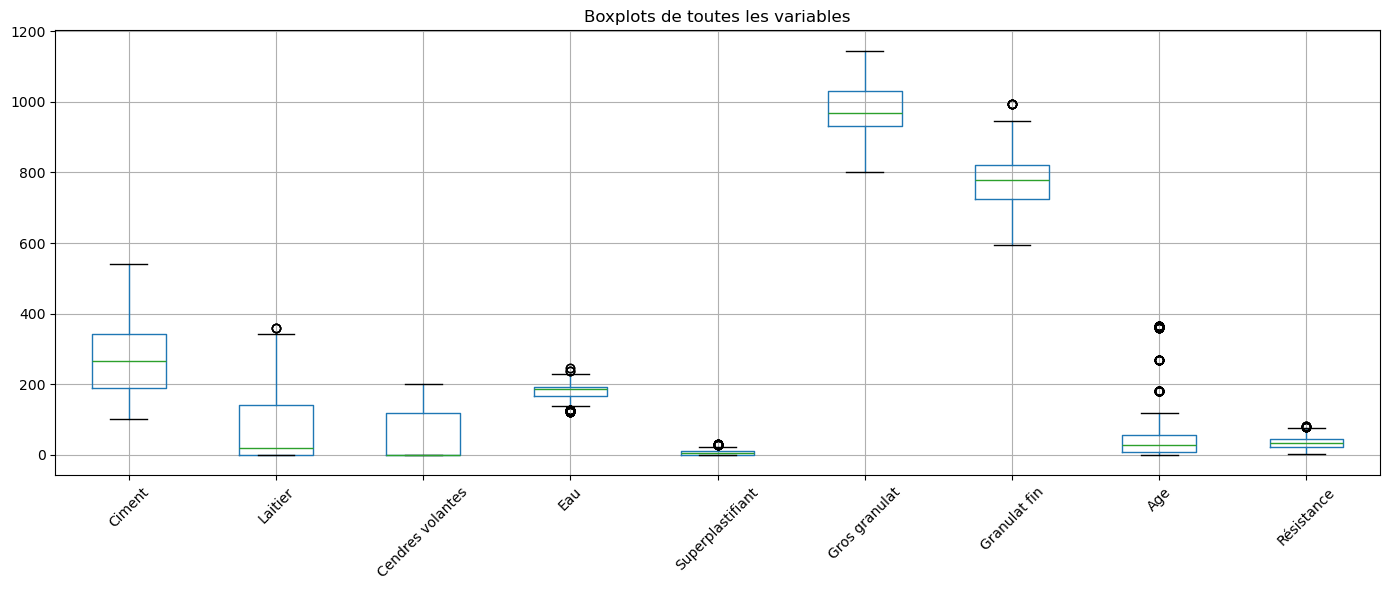

In [22]:
plt.figure(figsize=(14, 6))
df.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots de toutes les variables')
plt.tight_layout()
plt.show()

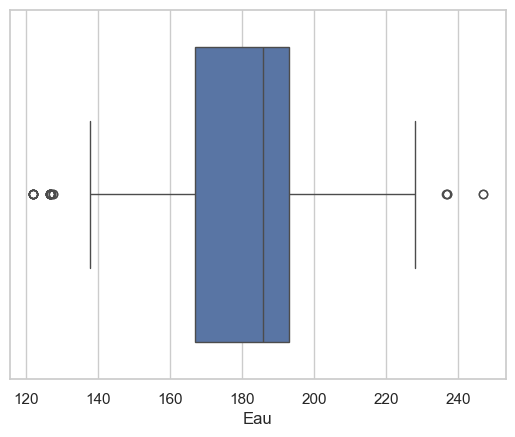

In [27]:
sns.set(style="whitegrid")
ax=sns.boxplot(data=df['Eau'],orient='h')

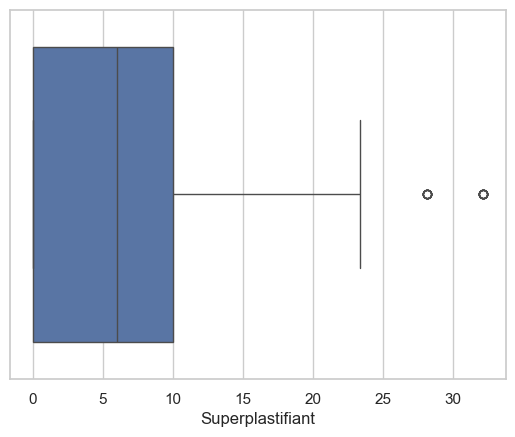

In [31]:
sns.set(style="whitegrid")
ax=sns.boxplot(data=df['Superplastifiant'],orient='h')

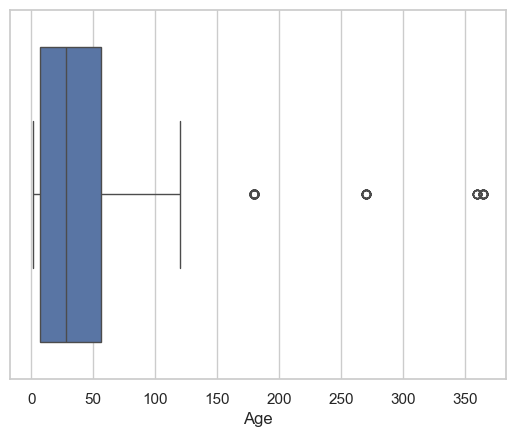

In [30]:
sns.set(style="whitegrid")
ax=sns.boxplot(data=df['Age'],orient='h')

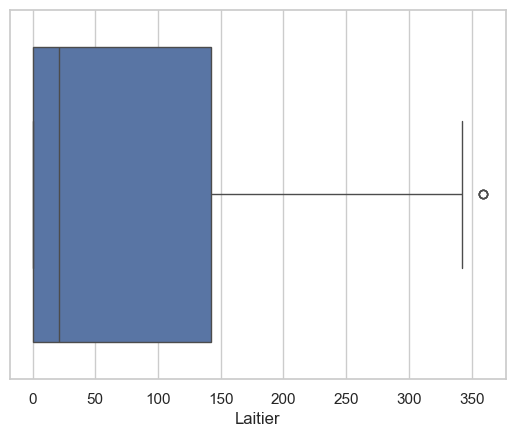

In [32]:
sns.set(style="whitegrid")
ax=sns.boxplot(data=df['Laitier'],orient='h')

In [33]:
def detect_outliers(df):
    outlier_counts = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)  # Premier quartile
        Q3 = df[column].quantile(0.75)  # Troisième quartile
        IQR = Q3 - Q1                  # Interquartile Range
        
        lower_bound = Q1 - 1.5 * IQR   # Limite inférieure
        upper_bound = Q3 + 1.5 * IQR   # Limite supérieure
        
        # Identification et comptage des points en dehors des limites
        outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
        outlier_counts[column] = outliers
        
    return outlier_counts

outlier_counts = detect_outliers(df)
total = 0
for column, count in outlier_counts.items():
    total += count
    print(f"Colonne '{column}': {count} outliers")
print('-' * 30)
print(f"Nombre total = {total}")

Colonne 'Ciment': 0 outliers
Colonne 'Laitier': 4 outliers
Colonne 'Cendres volantes': 0 outliers
Colonne 'Eau': 25 outliers
Colonne 'Superplastifiant': 17 outliers
Colonne 'Gros granulat': 0 outliers
Colonne 'Granulat fin': 8 outliers
Colonne 'Age': 102 outliers
Colonne 'Résistance': 13 outliers
------------------------------
Nombre total = 169


### 2. Distribution de la variable cible — Résistance

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Résistance'], kde=True, color='steelblue')
plt.title('Distribution de la Résistance du béton')
plt.xlabel('Résistance (MPa)')
plt.show()


### 3. Nuage de points — Age vs Résistance

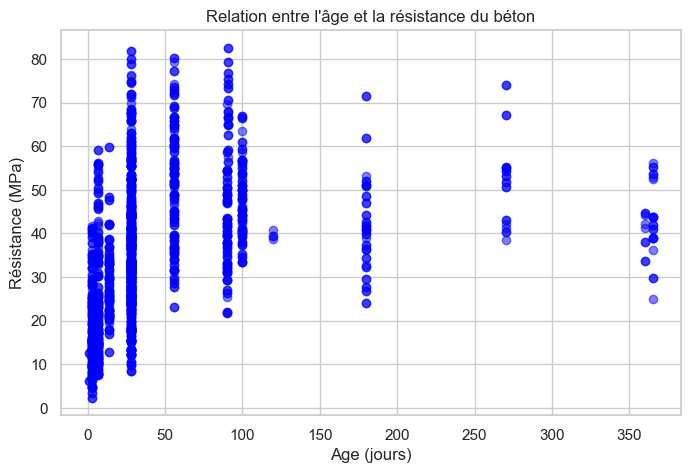

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Résistance'], color='blue', alpha=0.5)
plt.title("Relation entre l'âge et la résistance du béton")
plt.xlabel('Age (jours)')
plt.ylabel('Résistance (MPa)')
plt.show()


### 4. Nuage de points avec ligne de régression

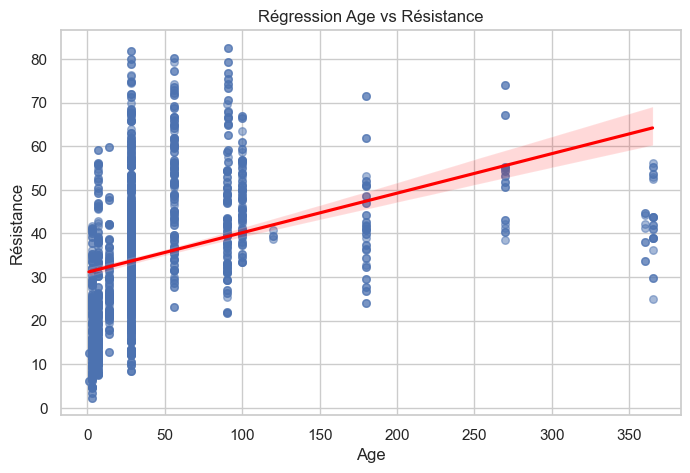

Coefficient de corrélation Age / Résistance : 0.3468


In [35]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Age', y='Résistance', data=df,
            scatter_kws={'s': 30, 'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title("Régression Age vs Résistance")
plt.show()

correlation = df['Age'].corr(df['Résistance'])
print(f'Coefficient de corrélation Age / Résistance : {correlation:.4f}')


### 5. Matrice de Corrélation

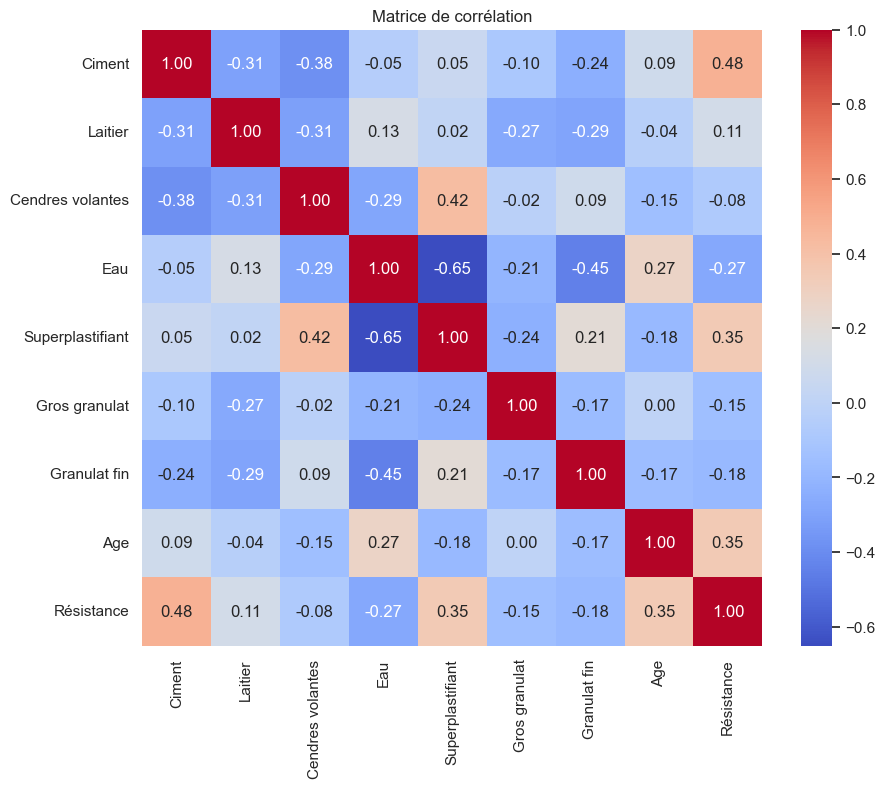

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()


# VI. Variables d'entrée X et Cible Y

### 1. Séparation X et y

In [37]:
X = df.drop('Résistance', axis=1)
y = df['Résistance']

print('X shape :', X.shape)
print('y shape :', y.shape)


X shape : (1764, 8)
y shape : (1764,)


### 2. Conversion en tableaux NumPy

In [38]:
    X = X.values
y = y.values

print('X (3 premières lignes) :')
print(X[:3])
print('y (3 premières valeurs) :', y[:3])


X (3 premières lignes) :
[[ 298.2     0.    107.    209.7    11.1   879.6   744.2    28.  ]
 [ 397.      0.      0.    186.      0.   1040.    734.     28.  ]
 [ 251.37    0.    118.27  188.45    6.35 1028.4   757.73   56.  ]]
y (3 premières valeurs) : [31.87516496 36.93522932 36.63875464]


# VIII. Division Train / Test

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)


X_train : (1411, 8)
X_test  : (353, 8)


# IX. Mise à l'Échelle — Standardisation

In [40]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('X_train_sc (3 premières lignes) :')
print(X_train_sc[:3])


X_train_sc (3 premières lignes) :
[[-0.77583538  0.67980849 -0.85043696  0.4552145  -1.02514537  0.05049663
   0.68987003  0.69394493]
 [-0.64768198 -0.85076363  1.08602706 -1.09909067  0.31242862  1.44135368
   0.36198357 -0.29391087]
 [ 0.49039669  1.11447248 -0.85043696  0.59651497  0.34672539 -2.12547972
   0.39351112 -0.29391087]]


# X. Modélisation avec Régression

**Choix des métriques :**

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **R²** | variance expliquée / variance totale | Plus proche de 1 = meilleur |
| **MAE** | moyenne des erreurs absolues | Erreur moyenne en MPa |
| **MSE** | moyenne des erreurs² | Pénalise les grandes erreurs |
| **RMSE** | √MSE | Erreur en mêmes unités que Résistance |
| **MAPE** | % erreur moyenne | Erreur relative en % |
| **MEDAE** | médiane des erreurs absolues | Robuste aux outliers |

## X.1 — Régression Linéaire

In [41]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

lr_r2    = r2_score(y_test, y_pred_lr)
lr_mae   = mean_absolute_error(y_test, y_pred_lr)
lr_mse   = mean_squared_error(y_test, y_pred_lr)
lr_rmse  = np.sqrt(lr_mse)
lr_mape  = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
lr_medae = median_absolute_error(y_test, y_pred_lr)

print('=== Régression Linéaire ===')
print(f'R²    : {lr_r2:.4f}')
print(f'MAE   : {lr_mae:.4f}')
print(f'MSE   : {lr_mse:.4f}')
print(f'RMSE  : {lr_rmse:.4f}')
print(f'MAPE  : {lr_mape:.4f} %')
print(f'MEDAE : {lr_medae:.4f}')


=== Régression Linéaire ===
R²    : 0.5621
MAE   : 8.1739
MSE   : 108.3933
RMSE  : 10.4112
MAPE  : 32.1492 %
MEDAE : 6.6138


### Evaluation — Régression Linéaire

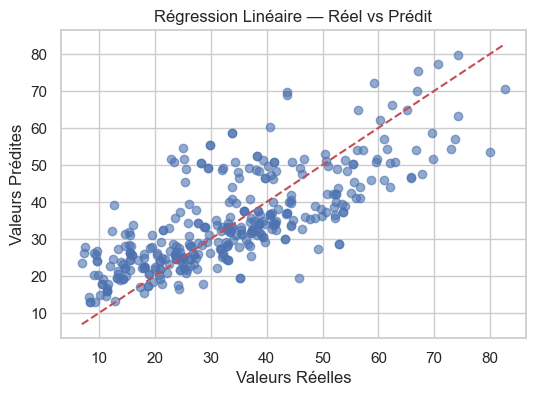

In [42]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valeurs Réelles')
plt.ylabel('Valeurs Prédites')
plt.title('Régression Linéaire — Réel vs Prédit')
plt.show()


## X.2 — Ridge et Lasso (Régularisation)

In [43]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

ridge_r2    = r2_score(y_test, y_pred_ridge)
ridge_mae   = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse   = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse  = np.sqrt(ridge_mse)
ridge_mape  = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
ridge_medae = median_absolute_error(y_test, y_pred_ridge)

print('=== Ridge ===')
print(f'R²    : {ridge_r2:.4f}')
print(f'MAE   : {ridge_mae:.4f}')
print(f'MSE   : {ridge_mse:.4f}')
print(f'RMSE  : {ridge_rmse:.4f}')
print(f'MAPE  : {ridge_mape:.4f} %')
print(f'MEDAE : {ridge_medae:.4f}')

# Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)

lasso_r2    = r2_score(y_test, y_pred_lasso)
lasso_mae   = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse   = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse  = np.sqrt(lasso_mse)
lasso_mape  = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100
lasso_medae = median_absolute_error(y_test, y_pred_lasso)

print()
print('=== Lasso ===')
print(f'R²    : {lasso_r2:.4f}')
print(f'MAE   : {lasso_mae:.4f}')
print(f'MSE   : {lasso_mse:.4f}')
print(f'RMSE  : {lasso_rmse:.4f}')
print(f'MAPE  : {lasso_mape:.4f} %')
print(f'MEDAE : {lasso_medae:.4f}')


=== Ridge ===
R²    : 0.5625
MAE   : 8.1750
MSE   : 108.2930
RMSE  : 10.4064
MAPE  : 32.1685 %
MEDAE : 6.6337

=== Lasso ===
R²    : 0.5243
MAE   : 8.8606
MSE   : 117.7493
RMSE  : 10.8512
MAPE  : 37.3660 %
MEDAE : 8.1759


## X.3 — ElasticNet

In [44]:
from sklearn.linear_model import ElasticNet

en = ElasticNet(alpha=1.0, l1_ratio=0.5)
en.fit(X_train_sc, y_train)
y_pred_en = en.predict(X_test_sc)

en_r2    = r2_score(y_test, y_pred_en)
en_mae   = mean_absolute_error(y_test, y_pred_en)
en_mse   = mean_squared_error(y_test, y_pred_en)
en_rmse  = np.sqrt(en_mse)
en_mape  = np.mean(np.abs((y_test - y_pred_en) / y_test)) * 100
en_medae = median_absolute_error(y_test, y_pred_en)

print('=== ElasticNet ===')
print(f'R²    : {en_r2:.4f}')
print(f'MAE   : {en_mae:.4f}')
print(f'MSE   : {en_mse:.4f}')
print(f'RMSE  : {en_rmse:.4f}')
print(f'MAPE  : {en_mape:.4f} %')
print(f'MEDAE : {en_medae:.4f}')


=== ElasticNet ===
R²    : 0.4745
MAE   : 9.4295
MSE   : 130.0773
RMSE  : 11.4051
MAPE  : 41.3259 %
MEDAE : 8.8388


## X.4 — Régression Polynomiale

In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('lr',   LinearRegression())
])
poly_pipeline.fit(X_train_sc, y_train)
y_pred_poly = poly_pipeline.predict(X_test_sc)

poly_r2    = r2_score(y_test, y_pred_poly)
poly_mae   = mean_absolute_error(y_test, y_pred_poly)
poly_mse   = mean_squared_error(y_test, y_pred_poly)
poly_rmse  = np.sqrt(poly_mse)
poly_mape  = np.mean(np.abs((y_test - y_pred_poly) / y_test)) * 100
poly_medae = median_absolute_error(y_test, y_pred_poly)

print('=== Régression Polynomiale (degree=2) ===')
print(f'R²    : {poly_r2:.4f}')
print(f'MAE   : {poly_mae:.4f}')
print(f'MSE   : {poly_mse:.4f}')
print(f'RMSE  : {poly_rmse:.4f}')
print(f'MAPE  : {poly_mape:.4f} %')
print(f'MEDAE : {poly_medae:.4f}')


=== Régression Polynomiale (degree=2) ===
R²    : 0.8014
MAE   : 5.4658
MSE   : 49.1563
RMSE  : 7.0112
MAPE  : 20.5019 %
MEDAE : 4.4993


## X.5 — Decision Tree Regressor

In [46]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

dt_r2    = r2_score(y_test, y_pred_dt)
dt_mae   = mean_absolute_error(y_test, y_pred_dt)
dt_mse   = mean_squared_error(y_test, y_pred_dt)
dt_rmse  = np.sqrt(dt_mse)
dt_mape  = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
dt_medae = median_absolute_error(y_test, y_pred_dt)

print('=== Decision Tree Regressor ===')
print(f'R²    : {dt_r2:.4f}')
print(f'MAE   : {dt_mae:.4f}')
print(f'MSE   : {dt_mse:.4f}')
print(f'RMSE  : {dt_rmse:.4f}')
print(f'MAPE  : {dt_mape:.4f} %')
print(f'MEDAE : {dt_medae:.4f}')


=== Decision Tree Regressor ===
R²    : 0.9532
MAE   : 1.3201
MSE   : 11.5748
RMSE  : 3.4022
MAPE  : 4.9954 %
MEDAE : 0.0034


## X.6 — Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

rf_r2    = r2_score(y_test, y_pred_rf)
rf_mae   = mean_absolute_error(y_test, y_pred_rf)
rf_mse   = mean_squared_error(y_test, y_pred_rf)
rf_rmse  = np.sqrt(rf_mse)
rf_mape  = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
rf_medae = median_absolute_error(y_test, y_pred_rf)

print('=== Random Forest Regressor ===')
print(f'R²    : {rf_r2:.4f}')
print(f'MAE   : {rf_mae:.4f}')
print(f'MSE   : {rf_mse:.4f}')
print(f'RMSE  : {rf_rmse:.4f}')
print(f'MAPE  : {rf_mape:.4f} %')
print(f'MEDAE : {rf_medae:.4f}')


=== Random Forest Regressor ===
R²    : 0.9707
MAE   : 1.6971
MSE   : 7.2573
RMSE  : 2.6939
MAPE  : 6.2139 %
MEDAE : 1.0389


## X.7 — Gradient Boosting Regressor + Grid Search

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_sc, y_train)
y_pred_gbr = gbr.predict(X_test_sc)

gbr_r2    = r2_score(y_test, y_pred_gbr)
gbr_mae   = mean_absolute_error(y_test, y_pred_gbr)
gbr_mse   = mean_squared_error(y_test, y_pred_gbr)
gbr_rmse  = np.sqrt(gbr_mse)
gbr_mape  = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
gbr_medae = median_absolute_error(y_test, y_pred_gbr)

print('=== Gradient Boosting (base) ===')
print(f'R²    : {gbr_r2:.4f}')
print(f'MAE   : {gbr_mae:.4f}')
print(f'RMSE  : {gbr_rmse:.4f}')


=== Gradient Boosting (base) ===
R²    : 0.9239
MAE   : 3.2752
RMSE  : 4.3391


### Grid Search — Gradient Boosting

In [49]:
params_gbr = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_gbr = GridSearchCV(GradientBoostingRegressor(random_state=42),
                        params_gbr, cv=3, scoring='r2')
grid_gbr.fit(X_train_sc, y_train)

best_model_gbr = grid_gbr.best_estimator_
y_pred_gbr     = best_model_gbr.predict(X_test_sc)

gbr_r2    = r2_score(y_test, y_pred_gbr)
gbr_mae   = mean_absolute_error(y_test, y_pred_gbr)
gbr_mse   = mean_squared_error(y_test, y_pred_gbr)
gbr_rmse  = np.sqrt(gbr_mse)
gbr_mape  = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
gbr_medae = median_absolute_error(y_test, y_pred_gbr)

print('Meilleurs paramètres :', grid_gbr.best_params_)
print()
print('=== Gradient Boosting (optimisé) ===')
print(f'R²    : {gbr_r2:.4f}')
print(f'MAE   : {gbr_mae:.4f}')
print(f'MSE   : {gbr_mse:.4f}')
print(f'RMSE  : {gbr_rmse:.4f}')
print(f'MAPE  : {gbr_mape:.4f} %')
print(f'MEDAE : {gbr_medae:.4f}')


Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

=== Gradient Boosting (optimisé) ===
R²    : 0.9743
MAE   : 1.5685
MSE   : 6.3593
RMSE  : 2.5218
MAPE  : 5.8334 %
MEDAE : 1.0483


### Importance des Features — Gradient Boosting

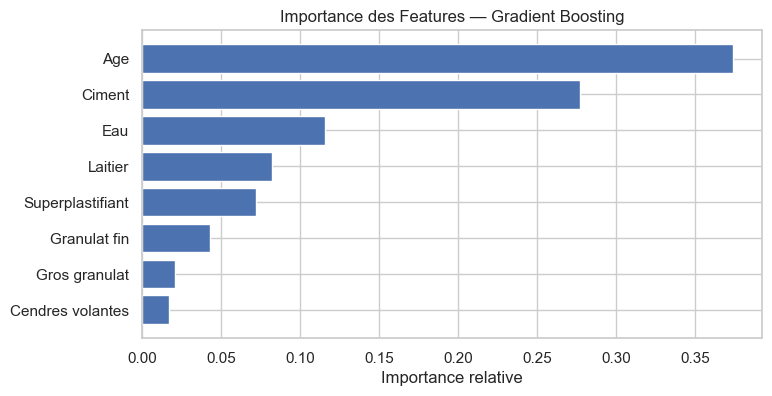

In [50]:
importances  = best_model_gbr.feature_importances_
feature_names = df.columns[:-1]
sorted_idx   = np.argsort(importances)
padding      = np.arange(len(feature_names))

plt.figure(figsize=(8, 4))
plt.barh(padding, importances[sorted_idx], align='center')
plt.yticks(padding, np.array(feature_names)[sorted_idx])
plt.xlabel('Importance relative')
plt.title('Importance des Features — Gradient Boosting')
plt.show()


## X.8 — XGBoost Regressor

In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42, eval_metric='rmse')
xgb.fit(X_train_sc, y_train)
y_pred_xgb = xgb.predict(X_test_sc)

xgb_r2    = r2_score(y_test, y_pred_xgb)
xgb_mae   = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse   = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse  = np.sqrt(xgb_mse)
xgb_mape  = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
xgb_medae = median_absolute_error(y_test, y_pred_xgb)

print('=== XGBoost Regressor ===')
print(f'R²    : {xgb_r2:.4f}')
print(f'MAE   : {xgb_mae:.4f}')
print(f'MSE   : {xgb_mse:.4f}')
print(f'RMSE  : {xgb_rmse:.4f}')
print(f'MAPE  : {xgb_mape:.4f} %')
print(f'MEDAE : {xgb_medae:.4f}')


=== XGBoost Regressor ===
R²    : 0.9769
MAE   : 1.2840
MSE   : 5.7195
RMSE  : 2.3916
MAPE  : 4.8255 %
MEDAE : 0.5990


## X.9 — LightGBM Regressor

In [52]:
#!pip install lightgbm
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(n_estimators=100, random_state=42)
lgbm.fit(X_train_sc, y_train)
y_pred_lgbm = lgbm.predict(X_test_sc)

lgbm_r2    = r2_score(y_test, y_pred_lgbm)
lgbm_mae   = mean_absolute_error(y_test, y_pred_lgbm)
lgbm_mse   = mean_squared_error(y_test, y_pred_lgbm)
lgbm_rmse  = np.sqrt(lgbm_mse)
lgbm_mape  = np.mean(np.abs((y_test - y_pred_lgbm) / y_test)) * 100
lgbm_medae = median_absolute_error(y_test, y_pred_lgbm)

print('=== LightGBM Regressor ===')
print(f'R²    : {lgbm_r2:.4f}')
print(f'MAE   : {lgbm_mae:.4f}')
print(f'MSE   : {lgbm_mse:.4f}')
print(f'RMSE  : {lgbm_rmse:.4f}')
print(f'MAPE  : {lgbm_mape:.4f} %')
print(f'MEDAE : {lgbm_medae:.4f}')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1207
[LightGBM] [Info] Number of data points in the train set: 1411, number of used features: 8
[LightGBM] [Info] Start training from score 35.656095
=== LightGBM Regressor ===
R²    : 0.9658
MAE   : 1.9634
MSE   : 8.4714
RMSE  : 2.9106
MAPE  : 7.3554 %
MEDAE : 1.3836


## X.10 — CatBoost Regressor

In [53]:
#!pip install catboost
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(iterations=100, random_state=42, verbose=0)
catboost_model.fit(X_train_sc, y_train)
y_pred_cat = catboost_model.predict(X_test_sc)

cat_r2    = r2_score(y_test, y_pred_cat)
cat_mae   = mean_absolute_error(y_test, y_pred_cat)
cat_mse   = mean_squared_error(y_test, y_pred_cat)
cat_rmse  = np.sqrt(cat_mse)
cat_mape  = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
cat_medae = median_absolute_error(y_test, y_pred_cat)

print('=== CatBoost Regressor ===')
print(f'R²    : {cat_r2:.4f}')
print(f'MAE   : {cat_mae:.4f}')
print(f'MSE   : {cat_mse:.4f}')
print(f'RMSE  : {cat_rmse:.4f}')
print(f'MAPE  : {cat_mape:.4f} %')
print(f'MEDAE : {cat_medae:.4f}')


=== CatBoost Regressor ===
R²    : 0.9662
MAE   : 2.0146
MSE   : 8.3709
RMSE  : 2.8932
MAPE  : 7.4097 %
MEDAE : 1.5882


### Importance des Features — CatBoost

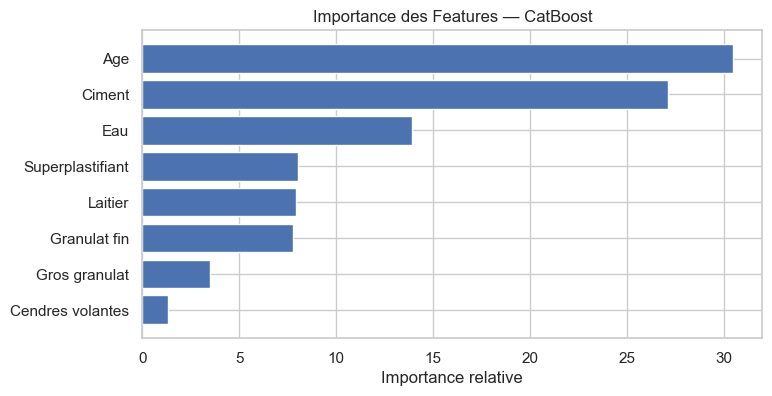

In [54]:
importances  = catboost_model.feature_importances_
feature_names = df.columns[:-1]
sorted_idx   = np.argsort(importances)
padding      = np.arange(len(feature_names))

plt.figure(figsize=(8, 4))
plt.barh(padding, importances[sorted_idx], align='center')
plt.yticks(padding, np.array(feature_names)[sorted_idx])
plt.xlabel('Importance relative')
plt.title('Importance des Features — CatBoost')
plt.show()


## X.11 — SVM Regressor

In [55]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf')
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)

svm_r2    = r2_score(y_test, y_pred_svm)
svm_mae   = mean_absolute_error(y_test, y_pred_svm)
svm_mse   = mean_squared_error(y_test, y_pred_svm)
svm_rmse  = np.sqrt(svm_mse)
svm_mape  = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100
svm_medae = median_absolute_error(y_test, y_pred_svm)

print('=== SVM Regressor ===')
print(f'R²    : {svm_r2:.4f}')
print(f'MAE   : {svm_mae:.4f}')
print(f'MSE   : {svm_mse:.4f}')
print(f'RMSE  : {svm_rmse:.4f}')
print(f'MAPE  : {svm_mape:.4f} %')
print(f'MEDAE : {svm_medae:.4f}')


=== SVM Regressor ===
R²    : 0.6938
MAE   : 6.6970
MSE   : 75.7795
RMSE  : 8.7051
MAPE  : 26.7371 %
MEDAE : 5.2180


## X.12 — KNN Regressor

In [56]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

knn_r2    = r2_score(y_test, y_pred_knn)
knn_mae   = mean_absolute_error(y_test, y_pred_knn)
knn_mse   = mean_squared_error(y_test, y_pred_knn)
knn_rmse  = np.sqrt(knn_mse)
knn_mape  = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
knn_medae = median_absolute_error(y_test, y_pred_knn)

print('=== KNN Regressor ===')
print(f'R²    : {knn_r2:.4f}')
print(f'MAE   : {knn_mae:.4f}')
print(f'MSE   : {knn_mse:.4f}')
print(f'RMSE  : {knn_rmse:.4f}')
print(f'MAPE  : {knn_mape:.4f} %')
print(f'MEDAE : {knn_medae:.4f}')


=== KNN Regressor ===
R²    : 0.7498
MAE   : 5.6150
MSE   : 61.9304
RMSE  : 7.8696
MAPE  : 21.1306 %
MEDAE : 4.2726


# 8. Summary — Comparaison de tous les modèles

In [57]:
algos = [
    'Linéaire', 'Ridge', 'Lasso', 'ElasticNet', 'Polynomiale',
    'Decision Tree', 'Random Forest', 'Gradient Boosting',
    'XGBoost', 'LightGBM', 'CatBoost', 'SVM', 'KNN'
]

r2_vals    = [lr_r2,   ridge_r2,   lasso_r2,   en_r2,   poly_r2,
              dt_r2,   rf_r2,      gbr_r2,
              xgb_r2,  lgbm_r2,    cat_r2,     svm_r2,  knn_r2]
mae_vals   = [lr_mae,  ridge_mae,  lasso_mae,  en_mae,  poly_mae,
              dt_mae,  rf_mae,     gbr_mae,
              xgb_mae, lgbm_mae,   cat_mae,    svm_mae, knn_mae]
mse_vals   = [lr_mse,  ridge_mse,  lasso_mse,  en_mse,  poly_mse,
              dt_mse,  rf_mse,     gbr_mse,
              xgb_mse, lgbm_mse,   cat_mse,    svm_mse, knn_mse]
rmse_vals  = [lr_rmse, ridge_rmse, lasso_rmse, en_rmse, poly_rmse,
              dt_rmse, rf_rmse,    gbr_rmse,
              xgb_rmse,lgbm_rmse,  cat_rmse,   svm_rmse,knn_rmse]
mape_vals  = [lr_mape, ridge_mape, lasso_mape, en_mape, poly_mape,
              dt_mape, rf_mape,    gbr_mape,
              xgb_mape,lgbm_mape,  cat_mape,   svm_mape,knn_mape]
medae_vals = [lr_medae,ridge_medae,lasso_medae,en_medae,poly_medae,
              dt_medae,rf_medae,   gbr_medae,
              xgb_medae,lgbm_medae,cat_medae,  svm_medae,knn_medae]

print(f"| {'Algorithm':<22} | {'R2':^8} | {'MAE':^8} | {'MSE':^10} | {'RMSE':^8} | {'MAPE':^8} | {'MEDAE':^8} |")
print('| ' + '-'*22 + ' | ' + ('-'*8+' | ')*6)
for a, r2, mae, mse, rmse, mape, medae in zip(
        algos, r2_vals, mae_vals, mse_vals, rmse_vals, mape_vals, medae_vals):
    print(f"| {a:<22} | {r2:^8.4f} | {mae:^8.4f} | {mse:^10.2f} | {rmse:^8.4f} | {mape:^8.4f} | {medae:^8.4f} |")


| Algorithm              |    R2    |   MAE    |    MSE     |   RMSE   |   MAPE   |  MEDAE   |
| ---------------------- | -------- | -------- | -------- | -------- | -------- | -------- | 
| Linéaire               |  0.5621  |  8.1739  |   108.39   | 10.4112  | 32.1492  |  6.6138  |
| Ridge                  |  0.5625  |  8.1750  |   108.29   | 10.4064  | 32.1685  |  6.6337  |
| Lasso                  |  0.5243  |  8.8606  |   117.75   | 10.8512  | 37.3660  |  8.1759  |
| ElasticNet             |  0.4745  |  9.4295  |   130.08   | 11.4051  | 41.3259  |  8.8388  |
| Polynomiale            |  0.8014  |  5.4658  |   49.16    |  7.0112  | 20.5019  |  4.4993  |
| Decision Tree          |  0.9532  |  1.3201  |   11.57    |  3.4022  |  4.9954  |  0.0034  |
| Random Forest          |  0.9707  |  1.6971  |    7.26    |  2.6939  |  6.2139  |  1.0389  |
| Gradient Boosting      |  0.9743  |  1.5685  |    6.36    |  2.5218  |  5.8334  |  1.0483  |
| XGBoost                |  0.9769  |  1.2840  |   

### Graphique comparatif — R² Score

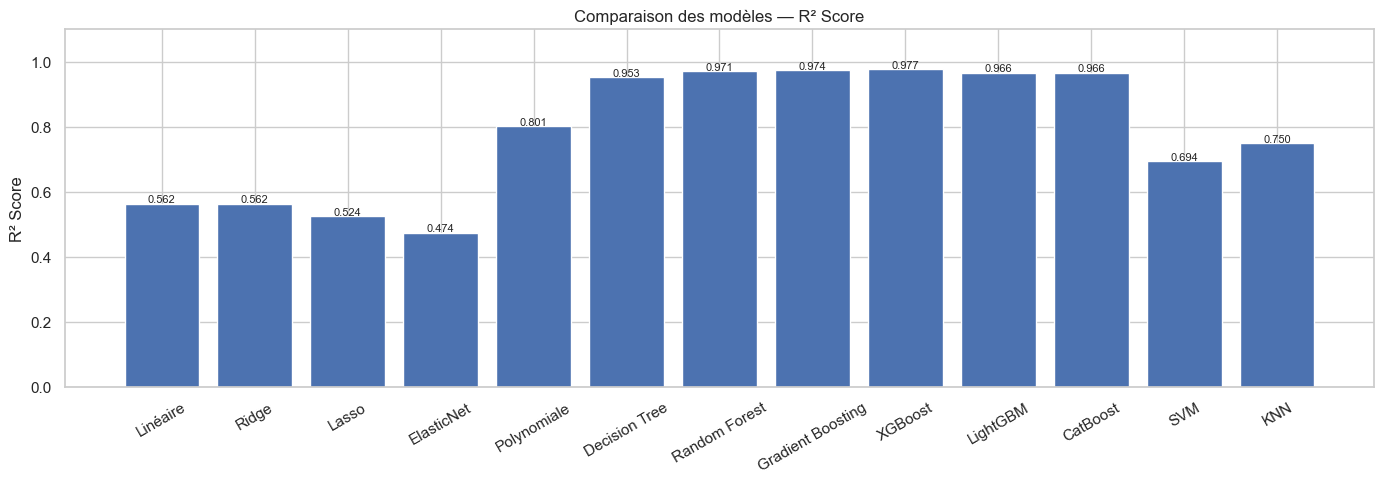

In [58]:
plt.figure(figsize=(14, 5))
barres = plt.bar(algos, r2_vals)
for b, s in zip(barres, r2_vals):
    plt.text(b.get_x() + b.get_width()/2,
             b.get_height() + 0.005,
             f'{s:.3f}', ha='center', fontsize=8)
plt.ylim(0, 1.1)
plt.ylabel('R² Score')
plt.title('Comparaison des modèles — R² Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


---
## Conclusion

In [59]:
best_idx   = int(np.argmax(r2_vals))
best_algo  = algos[best_idx]
best_r2    = r2_vals[best_idx]
best_mae   = mae_vals[best_idx]
best_rmse  = rmse_vals[best_idx]
best_mape  = mape_vals[best_idx]
best_medae = medae_vals[best_idx]

print('=' * 60)
print('          CONCLUSION — MEILLEUR MODÈLE')
print('=' * 60)
print(f'  Meilleur modèle : {best_algo}')
print(f'  R²              : {best_r2:.4f}')
print(f'  MAE             : {best_mae:.4f} MPa')
print(f'  RMSE            : {best_rmse:.4f} MPa')
print(f'  MAPE            : {best_mape:.4f} %')
print(f'  MEDAE           : {best_medae:.4f} MPa')
print('=' * 60)
print()
print('Classement par R² décroissant :')
classement = sorted(zip(algos, r2_vals), key=lambda x: x[1], reverse=True)
for rang, (nom, r2) in enumerate(classement, 1):
    print(f'  {rang:>2}. {nom:<22} → R² = {r2:.4f}')
print()
print(f'Le modèle {best_algo} est le meilleur car il obtient le R²')
print(f'le plus élevé ({best_r2:.4f}) ce qui signifie qu il explique')
print(f'{best_r2*100:.1f}% de la variance de la Résistance du béton.')
print(f'Ses prédictions sont en moyenne à {best_mae:.2f} MPa près')
print(f'de la valeur réelle (MAE = {best_mae:.4f}).')


          CONCLUSION — MEILLEUR MODÈLE
  Meilleur modèle : XGBoost
  R²              : 0.9769
  MAE             : 1.2840 MPa
  RMSE            : 2.3916 MPa
  MAPE            : 4.8255 %
  MEDAE           : 0.5990 MPa

Classement par R² décroissant :
   1. XGBoost                → R² = 0.9769
   2. Gradient Boosting      → R² = 0.9743
   3. Random Forest          → R² = 0.9707
   4. CatBoost               → R² = 0.9662
   5. LightGBM               → R² = 0.9658
   6. Decision Tree          → R² = 0.9532
   7. Polynomiale            → R² = 0.8014
   8. KNN                    → R² = 0.7498
   9. SVM                    → R² = 0.6938
  10. Ridge                  → R² = 0.5625
  11. Linéaire               → R² = 0.5621
  12. Lasso                  → R² = 0.5243
  13. ElasticNet             → R² = 0.4745

Le modèle XGBoost est le meilleur car il obtient le R²
le plus élevé (0.9769) ce qui signifie qu il explique
97.7% de la variance de la Résistance du béton.
Ses prédictions sont en moyenne à 